<a href="https://colab.research.google.com/github/Rogerio-mack/IA_2026S1/blob/main/AI_2026S1_Exercicio_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Classificação de Imagens com Keras/TensorFlow Sequential**





In [ ]:
#@markdown >
#@markdown **Atividade INDIVIDUAL ou EM DUPLA**
#@markdown
#@markdown > Nome **COMPLETO** e RA

Aluno1 = '' #@param {type:"string"}
RA1 = '' #@param {type:"string"}
#@markdown
Aluno2 = '' #@param {type:"string"}
RA2 = '' #@param {type:"string"}

suffix_file_1 = RA1.replace('.','')
suffix_file_2 = RA2.replace('.','')


# **Exercício**

1. Atividade **INDIVIDUAL OU em DUPLA**
2. Apenas **UM ALUNO DEVE POSTAR**
3. Postar o **notebook Python (arquivo .ipynb) 100% executável**

O arquivo abaixo contem imagens de dois tipos de flores (rosas e dentes de leão). As imagens estão em formato 180x180x1, isto é imagens 180x180 com um único canal (não RGB). As imagens de rosas e dentes de leão estão pastas separadas, o que pode ser empregado para construção de rótulos de classificação.



## Parte I
Empregue o Keras/TensorFlow para construir um modelo MLP (Multi Layer Perceptron, isto é, um modelo Sequencial do Keras/TensorFlow, somente com camadas densas(\*) de aprendizado de classificação das imagens. Isso pode ser feito linearizando as imagens 180x180 em arrays de tamanho 32400.

Esquematicamente o seu conjunto de exemplos será o seguinte:

```
            32400 array      classe
          _____________________________
imagem_1  1001010011100...  roses
imagem_2  1001010011100...  dandelion
imagem_3  1001010011100...  roses
imagem_4  1001010011100...  roses
imagem_5  1001010011100...  dandelion
...
```

Você pode empregar este notebook [TensorFlow: Penguins Example](https://colab.research.google.com/github/Rogerio-mack/IA_2026S1/blob/main/TensorFlow_Penguins_Example.ipynb) como exemplo/ponto de partida.

Organize adequadamente o seu notebook, com uma seção para cada um dos itens abaixo, colocando um texto mínimo explicativo (markdown) de cada seção:

1. Preparação dos dados (incluindo separação dos dados de treinamento e teste)
2. Configuração do Modelo Sequencial Denso
3. Treinamento do Modelo
4. Histórico do Treinamento (gráfico de evolução)
5. Classification Report





<br>
<br>

<small>
(*) Note que um modelo Multi Layer Perceptron, um modelo Sequencial do Keras/TensorFlow, somente com camadas densas <strong>não possui camadas de convolução.</strong>)

<br>
<br>


## Parte II

Execute a mesma classificação empregando o modelo de rede convolucional apresentado no [Tutorial de  Classificação de Imagens do Keras](https://www.tensorflow.org/tutorials/images/classification?hl=pt-br) e compare os resultados com os do modelo anterior.

```
num_classes = len(class_names)

model = Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])
```

Faça o código desta parte em uma única seção e ao final uma seção de conclusão analisando os resultados.

1. Modelo Convolucional
2. Conclusão


## Dados

In [ ]:
!wget https://github.com/Rogerio-mack/IA_2026S1/raw/refs/heads/main/grayscale_flower_photos_180x180.zip


--2026-05-20 16:46:52--  https://github.com/Rogerio-mack/IA_2026S1/raw/refs/heads/main/grayscale_flower_photos_180x180.zip
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Rogerio-mack/IA_2026S1/refs/heads/main/grayscale_flower_photos_180x180.zip [following]
--2026-05-20 16:46:52--  https://raw.githubusercontent.com/Rogerio-mack/IA_2026S1/refs/heads/main/grayscale_flower_photos_180x180.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 22327970 (21M) [application/zip]
Saving to: ‘grayscale_flower_photos_180x180.zip’

grayscale_flower_ph 100%[===================>]  21.29M  --.-KB/s    in 0.1s    

In [ ]:
!unzip -q /content/grayscale_flower_photos_180x180.zip

## Exemplos dos dados de Treinamento

Note, alguns pode parecer bastante estranhos, mas é um conjunto de dados real.

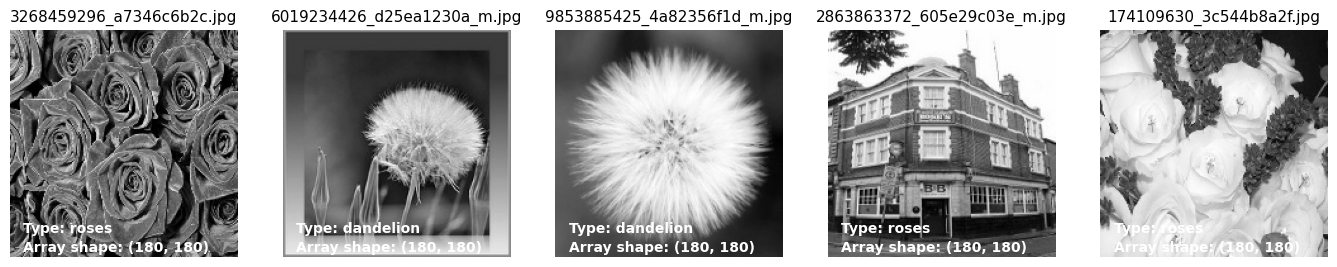

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pathlib

data_dir = pathlib.Path('/content/content/grayscale_flower_photos_180x180')

# List all image paths
image_paths = []
for class_dir in data_dir.iterdir():
    if class_dir.is_dir():
        for image_path in class_dir.glob('*.jpg'):
            image_paths.append(image_path)

if not image_paths:
    print(f"No images found in {data_dir}. Please ensure images have been processed and saved.")
else:
    plt.figure(figsize=(17, 4))
    for i in range(5):
      plt.subplot(1, 5, i + 1)
      random_image_path = random.choice(image_paths)
      img_array = mpimg.imread(str(random_image_path))

      plt.imshow(img_array, cmap='gray') # Use 'gray' colormap for grayscale images
      plt.title(f"{random_image_path.name}",fontsize=11)
      plt.text(10,175,f"Array shape: {img_array.shape}",color='white',fontsize=10,weight='bold')
      plt.text(10,160,f"Type: {str(random_image_path).split('/')[-2]}",color='white',fontsize=10,weight='bold')
      plt.axis('off')

    plt.show()

## **1. Preparação dos dados**

In [ ]:
# Seu texto e códigos

## **2. Configuração do Modelo Sequencial Denso**





In [ ]:
# Seu texto e códigos

## **3. Treinamento do Modelo**


In [ ]:
# Seu texto e códigos

## **4. Histórico do Treinamento**


In [ ]:
# Seu texto e códigos

## **5. Classification Report**

In [ ]:
# Seu texto e códigos

## **6. Modelo Convolucional**

In [ ]:
# Seu texto e códigos

## **7. Conclusão**

In [ ]:
# Seu texto e códigos